In [50]:
import torch
from pathlib import Path

from math550.topics.generative import (
    ConditionalMNISTFlowMatcher,
    ConditionalMNISTVAE,
    GaussianVAE,
    SUPPORTED_TORCH_DEVICES,
    TwoMoonsFlowMatcher,
    load_mnist,
    rbf_mmd_squared,
)

from math550.topics.generative.plotting import (
    plot_latent_samples,
    plot_learning_curves,
    plot_metric_comparison,
    plot_sample_grids,
    plot_sampling_tradeoff,
    plot_transport_trajectories,
)

checkpoint = Path("../../output/generative/models/mnist_28_vae.pt")

payload = torch.load(
    checkpoint,
    map_location="cpu",
    weights_only=True,
)

model = ConditionalMNISTVAE.from_state_dict(
    payload,
    device="cpu",
)

(50, 28, 28)


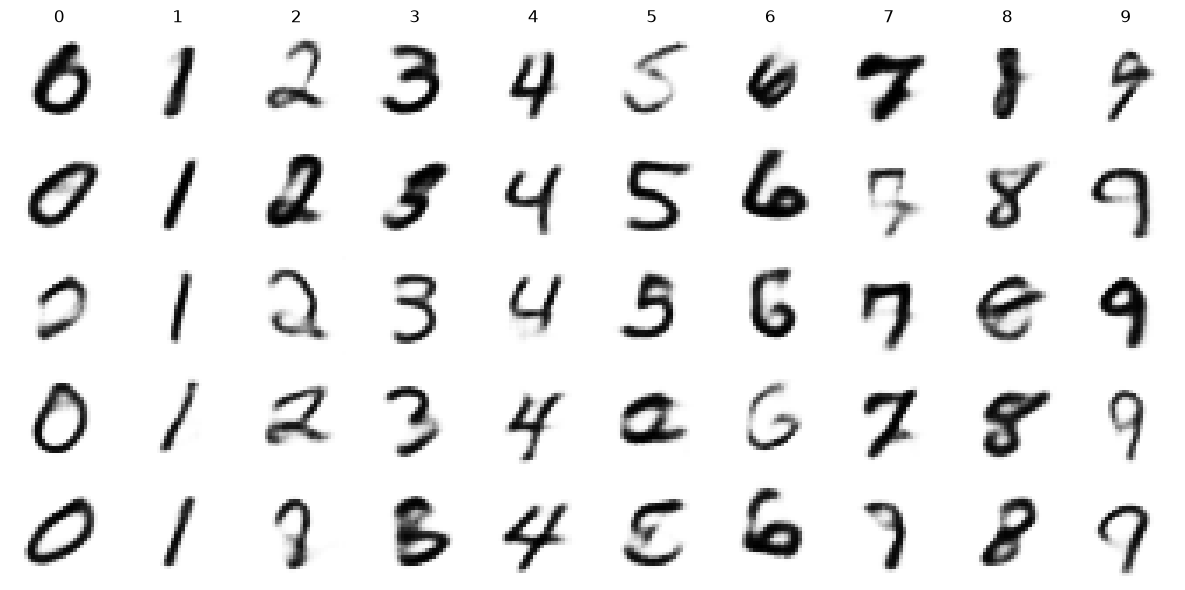

In [55]:
import numpy as np
import matplotlib.pyplot as plt

labels = np.tile(np.arange(10), 5)

generated = model.sample(
    labels,
    random_state=int(np.random.default_rng().integers(0, 2**31 - 1)),
)

print(generated.shape)

fig, axes = plt.subplots(5, 10, figsize=(12, 6))

for i, ax in enumerate(axes.flat):
    ax.imshow(generated[i], cmap="gray_r", vmin=0, vmax=1)
    ax.axis("off")

    # Label columns on the first row
    if i < 10:
        ax.set_title(str(labels[i]))

plt.tight_layout()
plt.show()